<a href="https://colab.research.google.com/github/Hi-ImEddy/AIO/blob/feature%2FM09W02/Text_to_Image_Flower_DCGAN_BERTs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Dataset**

In [ ]:
!gdown 1JJjMiNieTz7xYs6UeVqd02M3DW4fnEfU
!unzip cvpr2016_flowers.zip

Streaming output truncated to the last 5000 lines.
  inflating: content/cvpr2016_flowers/images/image_02041.jpg  
  inflating: content/cvpr2016_flowers/images/image_06550.jpg  
  inflating: content/cvpr2016_flowers/images/image_00556.jpg  
  inflating: content/cvpr2016_flowers/images/image_05695.jpg  
  inflating: content/cvpr2016_flowers/images/image_02732.jpg  
  inflating: content/cvpr2016_flowers/images/image_00112.jpg  
  inflating: content/cvpr2016_flowers/images/image_03424.jpg  
  inflating: content/cvpr2016_flowers/images/image_03702.jpg  
  inflating: content/cvpr2016_flowers/images/image_01316.jpg  
  inflating: content/cvpr2016_flowers/images/image_03391.jpg  
  inflating: content/cvpr2016_flowers/images/image_02503.jpg  
  inflating: content/cvpr2016_flowers/images/image_05044.jpg  
  inflating: content/cvpr2016_flowers/images/image_01633.jpg  
  inflating: content/cvpr2016_flowers/images/image_05305.jpg  
  inflating: content/cvpr2016_flowers/images/image_02522.jpg  
  in

In [ ]:
import os

def load_captions(captions_folder, image_folder):
    captions = {}
    image_files = os.listdir(image_folder)
    for image_file in image_files:
        image_name = image_file.split('.')[0]
        caption_file = os.path.join(captions_folder, image_name + ".txt")
        with open(caption_file, "r") as f:
            caption = f.readlines()[0].strip()
        if image_name not in captions:
                captions[image_name] = caption
    return captions

In [ ]:
captions_folder = "./content/cvpr2016_flowers/captions"
image_folder = "./content/cvpr2016_flowers/images"

captions = load_captions(captions_folder, image_folder)

In [ ]:
captions['image_01313']

'flower with multiple white petals peeling back from the center.'

## **Caption Encoder**

In [ ]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

bert_model = SentenceTransformer("all-mpnet-base-v2").to(device)

def encode_captions(captions):
    encoded_captions = {}
    for image_name in captions.keys():
        caption = captions[image_name]
        encoded_captions[image_name] = {
            'embed': torch.tensor(bert_model.encode(caption)),
            'text': caption
        }
    return encoded_captions

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
encoded_captions = encode_captions(captions)

In [ ]:
encoded_captions['image_01313']

{'embed': tensor([ 8.2323e-04, -2.2503e-02, -3.8771e-02,  3.4367e-02, -4.0684e-02,
          9.5354e-03,  3.5113e-02,  3.6865e-02,  6.1961e-02, -9.9160e-03,
          1.1047e-01, -6.6033e-02, -4.7555e-02, -2.5872e-03,  1.5864e-02,
         -2.2544e-02, -7.4908e-03,  1.5508e-02,  6.6533e-02, -3.1364e-02,
          6.6394e-03, -6.6745e-03, -8.4943e-03,  5.8506e-02,  2.8159e-02,
         -6.8209e-02, -3.1168e-02, -3.1902e-02,  1.8016e-02, -2.0944e-02,
          2.8717e-02, -1.7579e-02, -2.6495e-02, -5.7450e-02,  1.3396e-06,
         -3.5225e-02, -1.3897e-02, -3.4884e-03, -7.0081e-03, -2.1350e-02,
         -4.1457e-02, -2.2456e-02,  7.4699e-03,  2.5690e-02,  3.6534e-02,
          1.3188e-02, -1.6613e-02,  7.3492e-02,  8.9742e-03,  4.4904e-02,
          3.7980e-02, -2.5769e-02, -1.0529e-02,  2.7776e-02,  1.9198e-02,
          2.2026e-02,  1.8606e-02, -9.8877e-02, -1.2130e-01, -8.1141e-02,
         -1.5998e-02, -5.0306e-03, -3.2131e-02, -6.8181e-02, -5.1315e-02,
          3.8415e-03, -2.5069

##**Preprocess**


In [ ]:
from PIL import Image
from torch.utils.data import Dataset

class FlowerDataset(Dataset):
    def __init__(self, img_dir, captions, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # Load captions
        self.captions = captions

        self.img_names = list(self.captions.keys())

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name+".jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        encoded_caption = self.captions[img_name]['embed']
        caption = self.captions[img_name]['text']

        return {
            'image': image,
            'embed_caption': encoded_caption,
            'text': caption
        }

In [ ]:
import torchvision.transforms as transforms

IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

ds = FlowerDataset(
    img_dir="./content/cvpr2016_flowers/images",
    captions=encoded_captions,
    transform=transform
)

In [ ]:
import matplotlib.pyplot as plt

def show_grid(img):
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

In [ ]:
len(ds)

8189

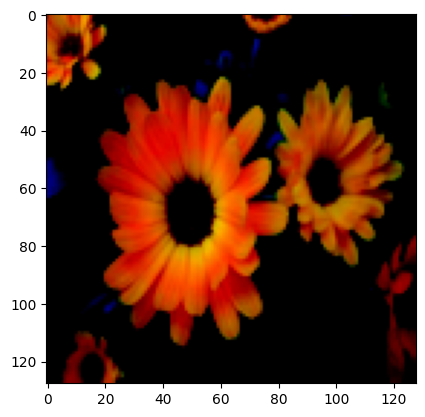

In [ ]:
show_grid(next(iter(ds))['image'])

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 1
dataloader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
batch_sample = next(iter(dataloader))

In [ ]:
batch_sample['image'].shape

torch.Size([1, 3, 128, 128])

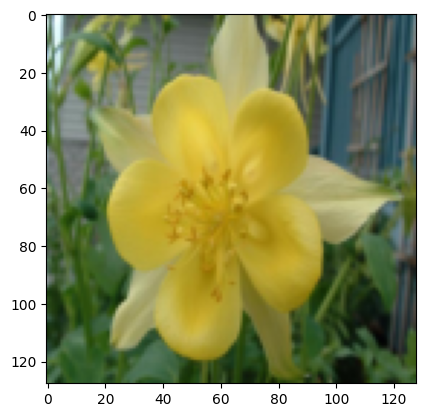

In [ ]:
import torchvision

show_grid(torchvision.utils.make_grid(batch_sample['image'], normalize=True))

## **Model**

In [ ]:
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self, noise_size, feature_size, num_channels, embedding_size, reduced_dim_size):
        super(Generator, self).__init__()
        self.reduced_dim_size = reduced_dim_size

        #768-->256
        self.textEncoder = nn.Sequential(
            nn.Linear(in_features = embedding_size, out_features = reduced_dim_size),
            nn.BatchNorm1d(num_features = reduced_dim_size),
            nn.LeakyReLU(negative_slope = 0.2, inplace = True)
        )

        self.upsamplingBlock = nn.Sequential(
            #256+100 --> 1024
            nn.ConvTranspose2d(noise_size + reduced_dim_size, feature_size * 8, 4, 1, 0, bias = False),
            nn.BatchNorm2d(feature_size * 8),
            nn.LeakyReLU(negative_slope = 0.2, inplace = True),

            # 1024 --> 512
            nn.ConvTranspose2d(feature_size * 8, feature_size * 4, 4, 2, 1, bias = False),
            nn.BatchNorm2d(feature_size * 4),
            nn.ReLU(True),

            # 512 --> 256
            nn.ConvTranspose2d(feature_size * 4, feature_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size * 2),
            nn.ReLU(True),

            # 256 --> 128
            nn.ConvTranspose2d(feature_size * 2, feature_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size),
            nn.ReLU(True),

            # 128 --> 128
            nn.ConvTranspose2d(feature_size, feature_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size),
            nn.ReLU(True),

            # 128 --> 3
            nn.ConvTranspose2d(feature_size, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()

        )

    def forward(self, noise, text_embeddings):
        encoded_text = self.textEncoder(text_embeddings)
        concat_input = torch.cat([noise, encoded_text], dim = 1).unsqueeze(2).unsqueeze(2)
        output = self.upsamplingBlock(concat_input)
        return output

In [ ]:
generator = Generator(100, 128, 3, 768, 256).to(device)

In [ ]:
generator

Generator(
  (textEncoder): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (upsamplingBlock): Sequential(
    (0): ConvTranspose2d(356, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), str

In [ ]:
class Discriminator(nn.Module):

    def __init__(self, num_channels, feature_size, embedding_size, reduced_dim_size):
        super(Discriminator, self).__init__()
        self.reduced_dim_size = reduced_dim_size

        self.imageEncoder = nn.Sequential(
            # 3 -> 128
            nn.Conv2d(num_channels, feature_size, 4, 2, 1, bias = False),
            nn.LeakyReLU(0.2, inplace = True),

            # 128 -> 128
            nn.Conv2d(feature_size, feature_size, 4, 2, 1, bias = False),
            nn.LeakyReLU(0.2, inplace = True),

            # 128 -> 256
            nn.Conv2d(feature_size, feature_size * 2, 4, 2, 1, bias = False),
            nn.BatchNorm2d(feature_size * 2),
            nn.LeakyReLU(0.2, inplace = True),

            # 256 -> 512
            nn.Conv2d(feature_size * 2, feature_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 512 -> 1024
            nn.Conv2d(feature_size * 4, feature_size * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size * 8),
            nn.LeakyReLU(0.2, inplace=True),

        )

        self.textEncoder = nn.Sequential(
            nn.Linear(in_features=embedding_size, out_features=reduced_dim_size),
            nn.BatchNorm1d(num_features=reduced_dim_size),
            nn.LeakyReLU(negative_slope=0.2, inplace=True)
        )

        self.finalBlock = nn.Sequential(
            nn.Conv2d(feature_size * 8 + reduced_dim_size, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )


    def forward(self, input_img, text_embeddings):
        image_encoded = self.imageEncoder(input_img)

        text_encoded = self.textEncoder(text_embeddings)

        replicated_text = text_encoded.repeat(4, 4, 1, 1).permute(2,  3, 0, 1)
        concat_layer = torch.cat([image_encoded, replicated_text], 1)

        x = self.finalBlock(concat_layer)

        return x.view(-1, 1)

In [ ]:
discriminator = Discriminator(3, 128, 768, 256).to(device)

In [ ]:
discriminator

Discriminator(
  (imageEncoder): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (8): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (11): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): LeakyReLU(negati

In [ ]:
bce_loss = nn.BCELoss()

In [ ]:
plt_o_text_embeddings = ds[0]['embed_caption'].unsqueeze(0)
plt_o_text_embeddings.shape

torch.Size([1, 768])

In [ ]:
fixed_noise = torch.randn(size=(1, 100))
fixed_noise.shape

torch.Size([1, 100])

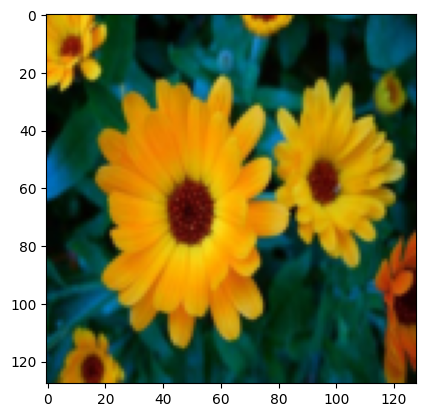

In [ ]:
show_grid(torchvision.utils.make_grid(ds[0]['image'], normalize=True))

## **Training**

In [ ]:
def plot_output(generator):
  plt.clf()
  with torch.no_grad():

    generator.eval()
    test_images = generator(fixed_noise.to(device), plt_o_text_embeddings.to(device))
    generator.train()

    grid = torchvision.utils.make_grid(test_images.cpu(), normalize=True)
    show_grid(grid)

In [ ]:
import torch.optim as optim

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

In [ ]:
import time

epochs = 500

for epoch in range(epochs):

    d_losses, g_losses = [], []

    epoch_time = time.time()

    for batch in dataloader:
        images = batch['image'].to(device)  # Đưa ảnh lên GPU
        embed_captions = batch['embed_caption'].to(device)  # Đưa captions lên GPU (đã là tensor)

        real_labels = torch.ones(images.size(0), 1, device=device)
        fake_labels = torch.zeros(images.size(0), 1, device=device)

        # Training the discriminator
        optimizer_D.zero_grad()

        noise = torch.randn(size=(images.size(0), 100), device=device)
        fake_images = generator(noise, embed_captions)

        real_labels = torch.ones(images.size(0), 1, device=device)
        fake_labels = torch.zeros(images.size(0), 1, device=device)

        real_loss = criterion(
            discriminator(images, embed_captions),
            real_labels
        )
        fake_loss = criterion(
            discriminator(fake_images.detach(), embed_captions),
            fake_labels
        )
        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        d_losses.append(d_loss.item())

        # Training generator
        optimizer_G.zero_grad()
        noise = torch.randn(size=(images.size(0), 100), device=device)
        fake_images = generator(noise, embed_captions)

        g_loss = criterion(
            discriminator(fake_images, embed_captions),
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

        g_losses.append(g_loss.item())

    avg_d_loss = sum(d_losses)/len(d_losses)
    avg_g_loss = sum(g_losses)/len(g_losses)

    if (epoch+1) % 10 == 0:
        plot_output(generator)

    print('Epoch [{}/{}] loss_D: {:.4f} loss_G: {:.4f} time: {:.2f}'.format(
        epoch+1, epochs,
        avg_d_loss,
        avg_g_loss,
        time.time() - epoch_time)
    )

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 256])

In [ ]:
import torch

# Save generator
torch.save(generator.state_dict(), 'generator_contrastive.pth')

# Save discriminator
torch.save(discriminator.state_dict(), 'discriminator_contrastive.pth')

In [ ]:
ds[4]['text']

'this pale pink flower has a large yellow and green pistil.'

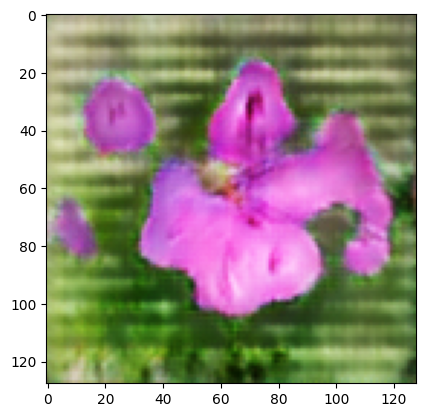

In [ ]:
generator.eval()

noise = torch.randn(size=(1, 100))
text_embedding = ds[4]['embed_caption'].unsqueeze(0)
with torch.no_grad():
    test_images = generator(noise.to(device), text_embedding.to(device))
grid = torchvision.utils.make_grid(test_images.cpu(), normalize=True)
show_grid(grid)